# FinMark Customer Segmentation using K-Means Clustering

## Project Overview
This project applies unsupervised machine learning to segment FinMark customers based on behavioral patterns.  
Using transaction data and customer feedback, we identify distinct customer personas that help FinMark better understand engagement, satisfaction, and revenue contribution.

## Objectives
- Integrate transaction and feedback datasets
- Engineer behavioral customer features
- Apply K-Means clustering for customer segmentation
- Identify meaningful customer personas
- Generate actionable business insights and recommendations

## Tools Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib & Seaborn

# FinMark Customer Segmentation using K-Means

## Table of Contents
# FinMark Customer Segmentation using K-Means

## Table of Contents
1. [Project Overview](#project-overview)
2. [1. Data Loading](#1-data-loading)
3. [2. Data Cleaning and Preparation](#2-data-cleaning-and-preparation)
4. [3. Feature Engineering](#3-feature-engineering)
5. [4. Determining the Optimal Number of Clusters](#4-determining-the-optimal-number-of-clusters)
6. [5. Customer Persona Identification](#5-customer-persona-identification)
7. [6. Customer Persona Visualization](#6-customer-persona-visualization)
8. [7. Cluster Visualization using PCA](#7-cluster-visualization-using-pca)
9. [8. Business Insights and Recommendations](#8-business-insights-and-recommendations)
10. [9. Conclusion](#9-conclusion)

## 1. Data Loading

We load two datasets:

- **Transaction Data** – contains purchase amounts and transaction frequency.
- **Customer Feedback Data** – contains satisfaction ratings and likelihood to recommend.

These datasets will later be aggregated at the **customer level** to support segmentation.

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set visualization style
sns.set(style="whitegrid")
%matplotlib inline

# Load the datasets
df_feedback = pd.read_csv('Customer_Feedback_Data.csv')
df_transaction = pd.read_csv('Transaction_Data.csv')

print("Data loaded successfully.")

Data loaded successfully.


## 2. Data Cleaning and Preparation

To ensure reliable clustering results, the data must be cleaned and standardized.

Key steps performed:
- Handling missing values using median imputation
- Correcting human entry errors in satisfaction scores
- Aggregating transaction and feedback data per customer
- Creating a unified customer-level dataset

In [7]:
# 1. Handle Missing Values robustly (using median to avoid outlier distortion)
df_transaction['Transaction_Amount'] = df_transaction['Transaction_Amount'].fillna(df_transaction['Transaction_Amount'].median())
df_feedback['Satisfaction_Score'] = df_feedback['Satisfaction_Score'].fillna(df_feedback['Satisfaction_Score'].median())
df_feedback['Likelihood_to_Recommend'] = df_feedback['Likelihood_to_Recommend'].fillna(df_feedback['Likelihood_to_Recommend'].median())

# 2. Fix Human-Entry Errors in Satisfaction Score (e.g., typing '80' instead of '8.0')
df_feedback['Satisfaction_Score'] = df_feedback['Satisfaction_Score'].apply(lambda x: x/10 if x > 10 else x)
df_feedback['Satisfaction_Score'] = df_feedback['Satisfaction_Score'].clip(upper=10) # Cap at maximum of 10

# 3. Aggregate Transactions per Customer
customer_spend = df_transaction.groupby('Customer_ID').agg(
    Total_Spending=('Transaction_Amount', 'sum'),
    Transaction_Frequency=('Transaction_Amount', 'count')
).reset_index()

# 4. Aggregate Feedback per Customer
customer_feedback = df_feedback.groupby('Customer_ID').agg(
    Average_Satisfaction=('Satisfaction_Score', 'mean'),
    Average_Recommendation=('Likelihood_to_Recommend', 'mean')
).reset_index()

# 5. Merge into a single Customer Master Table
df_customer = pd.merge(customer_spend, customer_feedback, on='Customer_ID', how='inner')

print(f"Aggregated data down to {df_customer.shape[0]} unique customers.")
df_customer.head()

Aggregated data down to 993 unique customers.


,Customer_ID,Total_Spending,Transaction_Frequency,Average_Satisfaction,Average_Recommendation
0,1,16836.0,6,8.500000,9.000000
1,2,4907.0,2,4.333333,5.000000
2,3,1538.0,1,8.333333,3.666667
3,4,8295.0,2,5.500000,3.333333
4,5,14798.0,5,6.444444,5.666667


## 3. Feature Engineering

Customer segmentation requires meaningful behavioral features.

The following features were engineered:

- **Total Spending** – cumulative transaction amount per customer
- **Transaction Frequency** – number of transactions per customer
- **Average Satisfaction Score** – mean satisfaction rating
- **Average Recommendation Score** – likelihood to recommend FinMark

### Log Transformation

Financial spending data is typically **highly skewed**, where a small number of customers contribute disproportionately large spending amounts.

To prevent extreme values from dominating distance-based clustering, we apply a **log transformation** to total spending.

In [9]:
# 1. Apply Log Transformation to handle heavy right-skew in financial spending
# This prevents extreme "whale" spenders from ruining the cluster distances
df_customer['Log_Total_Spending'] = np.log1p(df_customer['Total_Spending'])

# 2. Select the final features for clustering
features = ['Log_Total_Spending', 'Transaction_Frequency', 'Average_Satisfaction', 'Average_Recommendation']

# Create a clean dataframe for clustering
df_cluster_ready = df_customer.dropna(subset=features).copy()

# 3. Standardize the data so Spend and Satisfaction have equal mathematical weight
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_ready[features])

print("Data successfully transformed and scaled. Ready for K-Means.")

Data successfully transformed and scaled. Ready for K-Means.


In [10]:
print("Dataset Shape:", df_customer.shape)
print("\nFeature Summary:")
display(df_customer.describe())

Dataset Shape: (993, 6)

Feature Summary:


,Customer_ID,Total_Spending,Transaction_Frequency,Average_Satisfaction,Average_Recommendation,Log_Total_Spending
count,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,500.871098,15676.934542,5.085599,5.593122,5.568929,9.313327
std,288.630791,33710.740709,2.221986,1.387333,1.466760,0.707005
min,1.000000,286.000000,1.000000,1.000000,1.000000,5.659482
25%,251.000000,7789.000000,3.000000,4.666667,4.500000,8.960596
50%,502.000000,11978.000000,5.000000,5.600000,5.666667,9.390910
75%,750.000000,16766.000000,7.000000,6.500000,6.600000,9.727168
max,1000.000000,489516.000000,14.000000,10.000000,10.000000,13.101174


## 4. Determining the Optimal Number of Clusters

Before applying K-Means clustering, we evaluate multiple values of **k** using:

- **Elbow Method** – evaluates within-cluster variance
- **Silhouette Score** – measures cluster separation

These metrics help determine the number of clusters that best represents the natural structure of the data.

C:\Users\rona\.conda\envs\krobus\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rona\.conda\envs\krobus\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rona\.conda\envs\krobus\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\rona\.conda\envs\krobus\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known

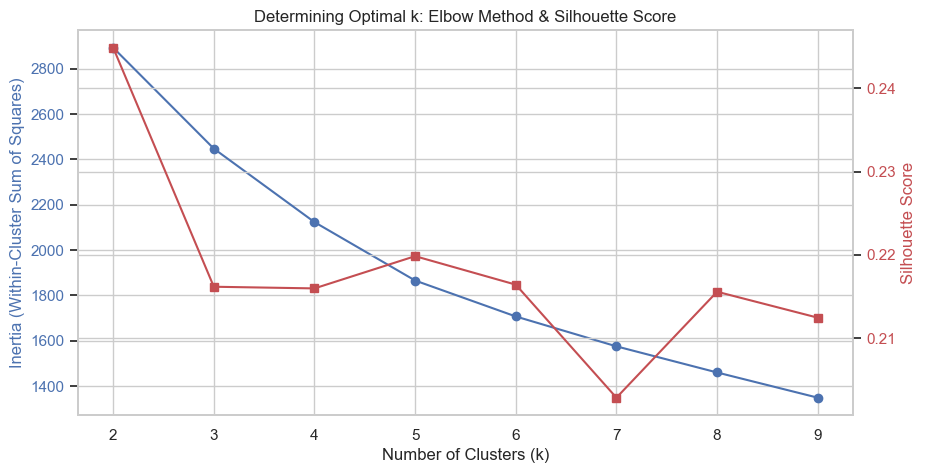

In [11]:
inertia = []
silhouette_scores = []
K_range = range(2, 10)

# Loop through potential cluster numbers
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting the results
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia (Elbow Method)
ax1.plot(K_range, inertia, marker='o', color='b', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Plot Silhouette Score
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, marker='s', color='r', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Determining Optimal k: Elbow Method & Silhouette Score')
plt.show()

### Interpretation

The elbow curve begins to stabilize around **k = 4**, indicating diminishing improvement in clustering performance beyond this point.

Silhouette scores also remain relatively stable around this value.

Therefore, **four clusters were selected** to balance statistical separation and meaningful business segmentation.

In [12]:
# Fit the final model with k=4 based on our business strategy
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

# Assign the cluster labels back to our dataset
df_cluster_ready['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Add descriptive names based on the behavior patterns
persona_names = {
    0: "Silent High-Spenders",
    1: "Vocal Critics",
    2: "Ideal Champions",
    3: "At-Risk Low Value"
}
df_cluster_ready['Persona'] = df_cluster_ready['Cluster'].map(persona_names)

# View the final Customer Profiles (Using the ORIGINAL, unscaled numbers for readability)
cluster_profiles = df_cluster_ready.groupby('Persona')[['Total_Spending', 'Transaction_Frequency', 'Average_Satisfaction', 'Average_Recommendation']].mean().round(2)

print("--- FINAL CUSTOMER PERSONAS ---")
display(cluster_profiles)

C:\Users\rona\.conda\envs\krobus\Lib\site-packages\sklearn\cluster\_kmeans.py:1411: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


--- FINAL CUSTOMER PERSONAS ---


,Total_Spending,Transaction_Frequency,Average_Satisfaction,Average_Recommendation
Persona,,,,
At-Risk Low Value,6335.47,2.98,4.87,5.70
Ideal Champions,33092.71,7.61,4.80,5.32
Silent High-Spenders,12650.74,5.01,6.47,4.00
Vocal Critics,13099.17,5.20,6.32,6.95


### Customer Persona Distribution

Understanding the size of each customer segment helps determine how representative each persona is within the overall customer base.

Balanced cluster sizes indicate that segmentation captures meaningful behavioral differences rather than being dominated by outliers.

C:\Users\rona\AppData\Local\Temp\ipykernel_43720\3710262143.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


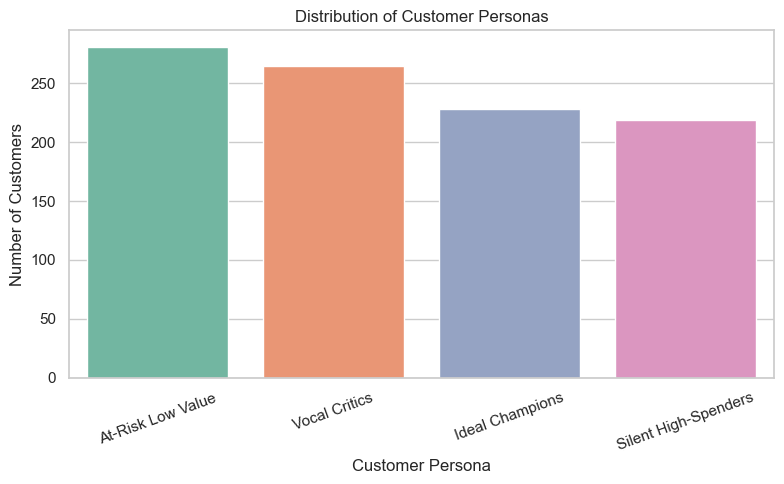

In [15]:
# Visualize how many customers belong to each persona
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_cluster_ready,
    x='Persona',
    order=df_cluster_ready['Persona'].value_counts().index,
    palette='Set2'
)

plt.title("Distribution of Customer Personas")
plt.xlabel("Customer Persona")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Insight

The distribution shows that all four personas represent meaningful portions of the customer base.

No single segment dominates the dataset, suggesting that the clustering algorithm captured natural behavioral groupings rather than extreme outliers.

## 5. Customer Persona Identification

After fitting the final K-Means model with **k = 4**, each customer is assigned to a cluster.

These clusters are interpreted as **customer personas**, based on behavioral patterns across spending, engagement, and satisfaction.

C:\Users\rona\AppData\Local\Temp\ipykernel_43720\2146222666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x=cluster_profiles.index, y=cluster_profiles['Total_Spending'], palette='Set2')
C:\Users\rona\AppData\Local\Temp\ipykernel_43720\2146222666.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x=cluster_profiles.index, y=cluster_profiles['Transaction_Frequency'], palette='Set2')
C:\Users\rona\AppData\Local\Temp\ipykernel_43720\2146222666.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0

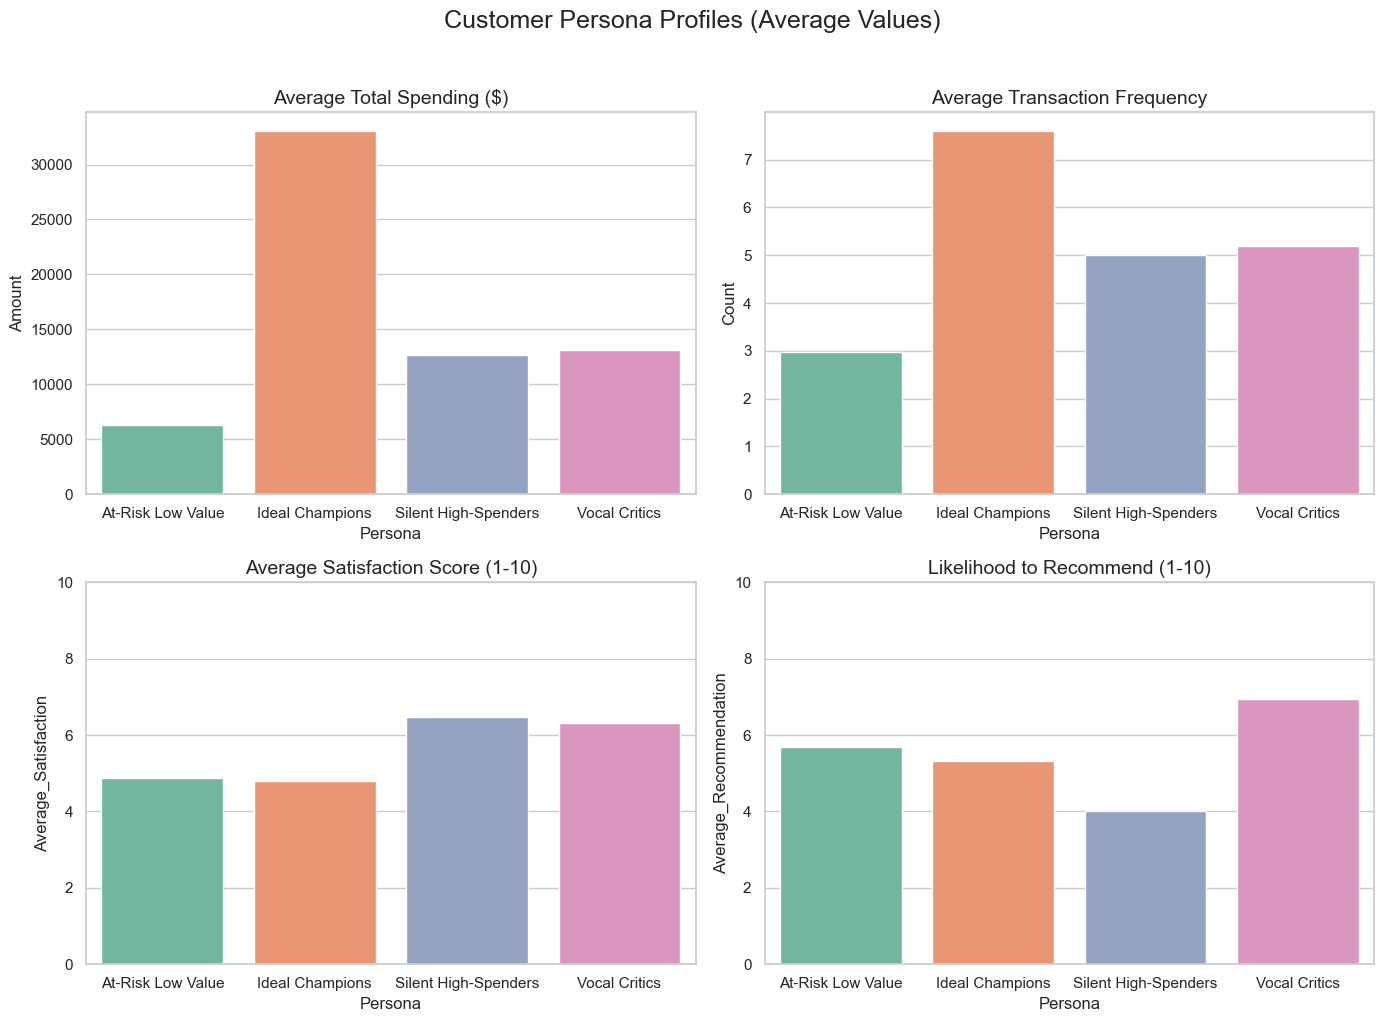

In [13]:
# Create a 2x2 grid of bar charts to visualize the Persona characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Persona Profiles (Average Values)', fontsize=18, y=1.02)

# 1. Spending Chart
sns.barplot(ax=axes[0, 0], x=cluster_profiles.index, y=cluster_profiles['Total_Spending'], palette='Set2')
axes[0, 0].set_title('Average Total Spending ($)', fontsize=14)
axes[0, 0].set_ylabel('Amount')

# 2. Frequency Chart
sns.barplot(ax=axes[0, 1], x=cluster_profiles.index, y=cluster_profiles['Transaction_Frequency'], palette='Set2')
axes[0, 1].set_title('Average Transaction Frequency', fontsize=14)
axes[0, 1].set_ylabel('Count')

# 3. Satisfaction Chart
sns.barplot(ax=axes[1, 0], x=cluster_profiles.index, y=cluster_profiles['Average_Satisfaction'], palette='Set2')
axes[1, 0].set_title('Average Satisfaction Score (1-10)', fontsize=14)
axes[1, 0].set_ylim(0, 10)

# 4. Recommendation Chart
sns.barplot(ax=axes[1, 1], x=cluster_profiles.index, y=cluster_profiles['Average_Recommendation'], palette='Set2')
axes[1, 1].set_title('Likelihood to Recommend (1-10)', fontsize=14)
axes[1, 1].set_ylim(0, 10)

# Clean up layout and display
plt.tight_layout()
plt.show()

### Persona Interpretation

The clustering analysis reveals four distinct customer segments:

**1. Ideal Champions**
- Highest spending and engagement levels
- Valuable and loyal customers
- Prime candidates for loyalty programs

**2. Silent High-Spenders**
- High spending but lower recommendation scores
- May be satisfied but not actively advocating the brand

**3. Vocal Critics**
- Moderate spending but high recommendation activity
- Likely engaged customers who provide strong feedback

**4. At-Risk Low Value**
- Low spending and engagement
- Potential churn risk

### Behavioral Differences Between Personas

The persona charts highlight clear behavioral distinctions:

- **Ideal Champions** contribute the highest revenue and engagement.
- **Silent High-Spenders** spend significantly but exhibit weaker advocacy.
- **Vocal Critics** show stronger recommendation behavior despite moderate spending.
- **At-Risk Low Value customers** show minimal engagement across all metrics.

These differences confirm that **customer value cannot be determined by spending alone**, and behavioral sentiment plays a crucial role.

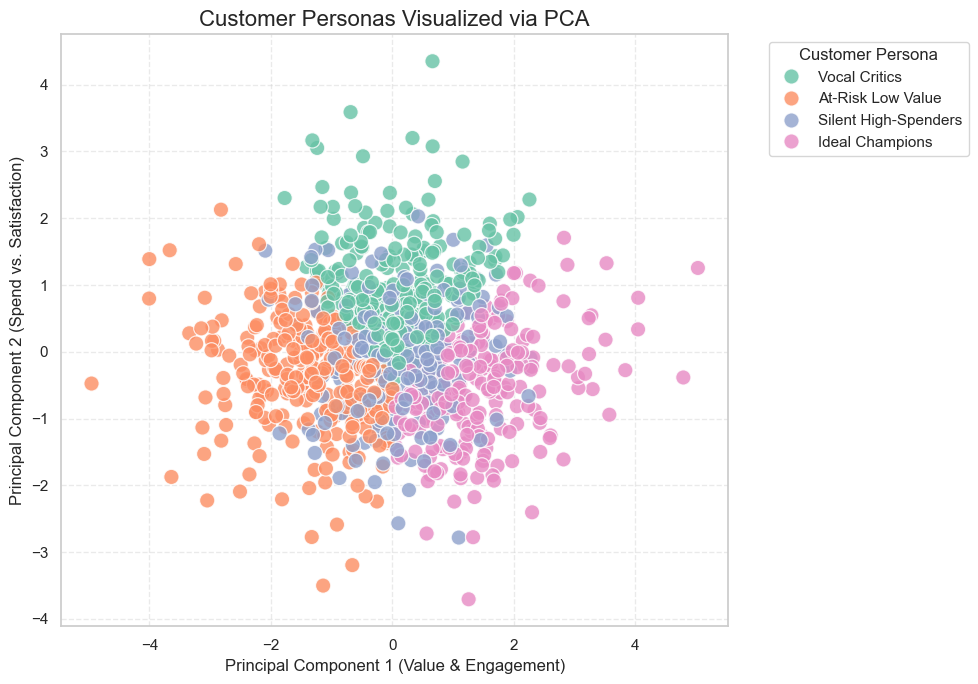

In [14]:
from sklearn.decomposition import PCA

# 1. Compress the scaled 4D data into 2 Principal Components
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# 2. Create a DataFrame for plotting
pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
pca_df['Persona'] = df_cluster_ready['Persona'].values

# 3. Create the Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Persona', 
    palette='Set2', 
    s=120,          # Size of the dots
    alpha=0.8,      # Slight transparency to see overlapping dots
    edgecolor='w'
)

# 4. Add labels explaining what the axes mean based on PCA loadings
plt.title('Customer Personas Visualized via PCA', fontsize=16)
plt.xlabel('Principal Component 1 (Value & Engagement)')
plt.ylabel('Principal Component 2 (Spend vs. Satisfaction)')
plt.legend(title='Customer Persona', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Visualizing Customer Segments

Principal Component Analysis (PCA) was used to reduce the four behavioral features into two dimensions for visualization.

Although clustering was performed in four-dimensional space, PCA allows us to observe how customers group together visually.

### Interpretation

The plot shows moderate separation between the four personas, indicating meaningful segmentation based on behavioral patterns.

Clusters are distributed along two main axes:

- **Value & Engagement** (spending and frequency)
- **Spend vs Satisfaction trade-off**

## 7. Business Insights and Recommendations

Based on the identified customer personas, FinMark can implement targeted strategies:

### Ideal Champions
- Offer VIP loyalty rewards
- Provide exclusive financial products
- Encourage referral programs

### Silent High-Spenders
- Introduce referral incentives
- Strengthen brand advocacy programs
- Engage through personalized outreach

### Vocal Critics
- Gather detailed feedback through surveys
- Address pain points to improve satisfaction
- Convert critical users into brand advocates

### At-Risk Low Value
- Deploy targeted promotions
- Introduce onboarding support
- Encourage initial engagement through incentives

These segmentation insights allow FinMark to move from **generic customer strategies to personalized engagement models.**

## Conclusion

This analysis applied K-Means clustering to identify behavioral segments among FinMark customers based on spending, engagement, and satisfaction metrics.

Four meaningful customer personas emerged:

• **Ideal Champions** – high-value, highly engaged customers  
• **Silent High-Spenders** – strong revenue contributors but weaker advocates  
• **Vocal Critics** – engaged customers who provide strong feedback  
• **At-Risk Low Value** – low engagement and potential churn risk  

These segments reveal that customer value is multidimensional and cannot be measured by spending alone.

By using behavioral segmentation, FinMark can implement targeted strategies such as loyalty programs, referral incentives, and proactive retention campaigns.

This approach allows FinMark to transition from generic marketing strategies to **data-driven customer engagement.**